In [ ]:
# Cell 1 — Install & Import Dependencies
!pip install -q torchinfo scikit-learn matplotlib seaborn

import os, re, time, copy, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torchinfo import summary

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [ ]:
# Cell 2 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


In [ ]:
# Cell 3 — GLOBAL CONFIGURATION (edit only here)
# ---------------------------------------------------------------
BASE_DIR  = '/content/drive/MyDrive/HandVein_Project/processed'
DB1_DIR   = os.path.join(BASE_DIR, 'db1')   # Training source
DB2_DIR   = os.path.join(BASE_DIR, 'db2')   # Test source

# Filter: 'roi' | 'blackhat' | 'frangi'
FILTER_TYPE = 'roi'

NUM_CLASSES   = 113
MAX_PERSON_ID = 113
IMAGE_SIZE    = 224
VALID_HANDS   = ['L', 'R']

BATCH_SIZE    = 32
NUM_EPOCHS    = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4

SAVE_DIR = '/content/drive/MyDrive/HandVein_Project/models'
os.makedirs(SAVE_DIR, exist_ok=True)

print('Configuration loaded.')
print(f'  Filter  : {FILTER_TYPE}')
print(f'  Classes : {NUM_CLASSES}')
print(f'  Train DB1 | Test DB2')
print(f'  Epochs  : {NUM_EPOCHS} | Batch : {BATCH_SIZE} | LR : {LEARNING_RATE}')

Configuration loaded.
  Filter  : roi
  Classes : 113
  Train DB1 | Test DB2
  Epochs  : 30 | Batch : 32 | LR : 0.001


In [ ]:
# Cell 4 — Filename Parser & Dataset Scanner

# Pattern: person_001_db1_L1_roi.png
FNAME_PATTERN = re.compile(
    r'^person_(\d{3})_db(\d)_([LR])(\d+)_([a-zA-Z]+)\.png$',
    re.IGNORECASE
)

def parse_filename(fname):
    m = FNAME_PATTERN.match(fname)
    if m is None:
        return None
    return {
        'person_id'  : int(m.group(1)),
        'db'         : int(m.group(2)),
        'hand'       : m.group(3).upper(),
        'img_num'    : int(m.group(4)),
        'filter_type': m.group(5).lower(),
        'class_label': int(m.group(1)) - 1,
    }

def scan_database(db_root, db_number, filter_type, max_person_id):
    records = []
    if not os.path.isdir(db_root):
        raise FileNotFoundError(
            f'Directory not found: {db_root}\nCheck BASE_DIR in Cell 3.'
        )
    for person_folder in sorted(os.listdir(db_root)):
        person_path = os.path.join(db_root, person_folder)
        if not os.path.isdir(person_path):
            continue
        for fname in sorted(os.listdir(person_path)):
            meta = parse_filename(fname)
            if meta is None:
                continue
            if meta['filter_type'] != filter_type:
                continue
            if meta['db'] != db_number:
                continue
            if meta['person_id'] > max_person_id:
                continue
            if meta['hand'] not in VALID_HANDS:
                continue
            meta['filepath'] = os.path.join(person_path, fname)
            records.append(meta)
    if not records:
        raise ValueError(
            f'No images found in {db_root} for filter={filter_type}, '
            f'db={db_number}, persons 001-{max_person_id:03d}.'
        )
    df = pd.DataFrame(records)
    df = df.sort_values(['person_id','hand','img_num']).reset_index(drop=True)
    return df

print(f'Scanning DB1 for filter="{FILTER_TYPE}" ...')
df_train = scan_database(DB1_DIR, 1, FILTER_TYPE, MAX_PERSON_ID)

print(f'Scanning DB2 for filter="{FILTER_TYPE}" ...')
df_test = scan_database(DB2_DIR, 2, FILTER_TYPE, MAX_PERSON_ID)

print('='*55)
print(f'  TRAIN (DB1) — {len(df_train):>5} images | {df_train["person_id"].nunique()} persons')
print(f'  TEST  (DB2) — {len(df_test):>5} images | {df_test["person_id"].nunique()} persons')
print('='*55)

train_persons = set(df_train['person_id'].unique())
test_persons  = set(df_test['person_id'].unique())
only_train = train_persons - test_persons
only_test  = test_persons  - train_persons
if only_train:
    print(f'WARNING: Persons in TRAIN but not TEST: {sorted(only_train)}')
if only_test:
    print(f'WARNING: Persons in TEST but not TRAIN: {sorted(only_test)}')
if not only_train and not only_test:
    print('All 113 persons present in both DB1 and DB2.')

print('\nDB1 images per person:')
print(df_train.groupby('person_id').size().describe())
print('\nDB2 images per person:')
print(df_test.groupby('person_id').size().describe())

Scanning DB1 for filter="roi" ...
Scanning DB2 for filter="roi" ...
  TRAIN (DB1) —   904 images | 113 persons
  TEST  (DB2) —   678 images | 113 persons
All 113 persons present in both DB1 and DB2.

DB1 images per person:
count    113.0
mean       8.0
std        0.0
min        8.0
25%        8.0
50%        8.0
75%        8.0
max        8.0
dtype: float64

DB2 images per person:
count    113.0
mean       6.0
std        0.0
min        6.0
25%        6.0
50%        6.0
75%        6.0
max        6.0
dtype: float64


In [ ]:
# Cell 5 — Custom Dataset & DataLoaders (FIXED FOR 113-CLASS VEIN-CNN)

from PIL import ImageOps

class HandVeinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        unique_persons = sorted(self.df['person_id'].unique())
        self.person_to_label = {p: i for i, p in enumerate(unique_persons)}
        self.label_to_person = {i: p for p, i in self.person_to_label.items()}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = self.person_to_label[row['person_id']]
        try:
            # FIX 1: Load as 1-channel Grayscale instead of converting to RGB
            img = Image.open(row['filepath']).convert('L')
        except FileNotFoundError:
            raise FileNotFoundError(
                f'Image not found: {row["filepath"]}\nCheck Drive structure.'
            )

        # FIX 2: Apply adaptive contrast adjustment so the veins visually pop out
        # from the surrounding skin tissue background before transforms
        img = ImageOps.autocontrast(img, cutoff=2)

        if self.transform:
            img = self.transform(img)
        return img, label

    def class_counts(self):
        counts = defaultdict(int)
        for pid in self.df['person_id']:
            counts[self.person_to_label[pid]] += 1
        return dict(counts)


# FIX 3: Replaced generic ImageNet color channel metrics with a single-channel,
# zero-centered baseline tailored for raw infrared grayscale images.
VEIN_MEAN = [0.5]
VEIN_STD  = [0.5]

# Optimized Augmentation Pipeline:
# Bridges the 2-month temporal gap without destroying biological features.
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # 1. REMOVED RandomHorizontalFlip entirely to stop Left vs Right hand confusion.

    # 2. Tightened rotation to a micro-scale to preserve sharp lines and reduce black corners.
    transforms.RandomRotation(degrees=3),

    # 3. Replaced heavy color jitter with very mild, non-destructive illumination variance.
    transforms.ColorJitter(brightness=0.05, contrast=0.05),

    # 4. Added tiny translation shifts (max 2% pixel movement) to mimic natural human placement error.
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),

    transforms.ToTensor(),
    transforms.Normalize(mean=VEIN_MEAN, std=VEIN_STD),
])

# Test transforms mirror the new grayscale normalization structure perfectly
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=VEIN_MEAN, std=VEIN_STD),
])

# Dataset Instantiation
train_dataset = HandVeinDataset(df_train, transform=train_transform)
test_dataset  = HandVeinDataset(df_test,  transform=test_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=2,
    pin_memory=(DEVICE.type == 'cuda')
)
test_loader = DataLoader(
    test_dataset,  batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2,
    pin_memory=(DEVICE.type == 'cuda')
)

print('Datasets ready with corrected single-channel biometric parameters.')
print(f'   Train samples : {len(train_dataset)}')
print(f'   Test  samples : {len(test_dataset)}')
print(f'   Train batches : {len(train_loader)}')
print(f'   Test  batches : {len(test_loader)}')

Datasets ready with corrected single-channel biometric parameters.
   Train samples : 904
   Test  samples : 678
   Train batches : 29
   Test  batches : 22


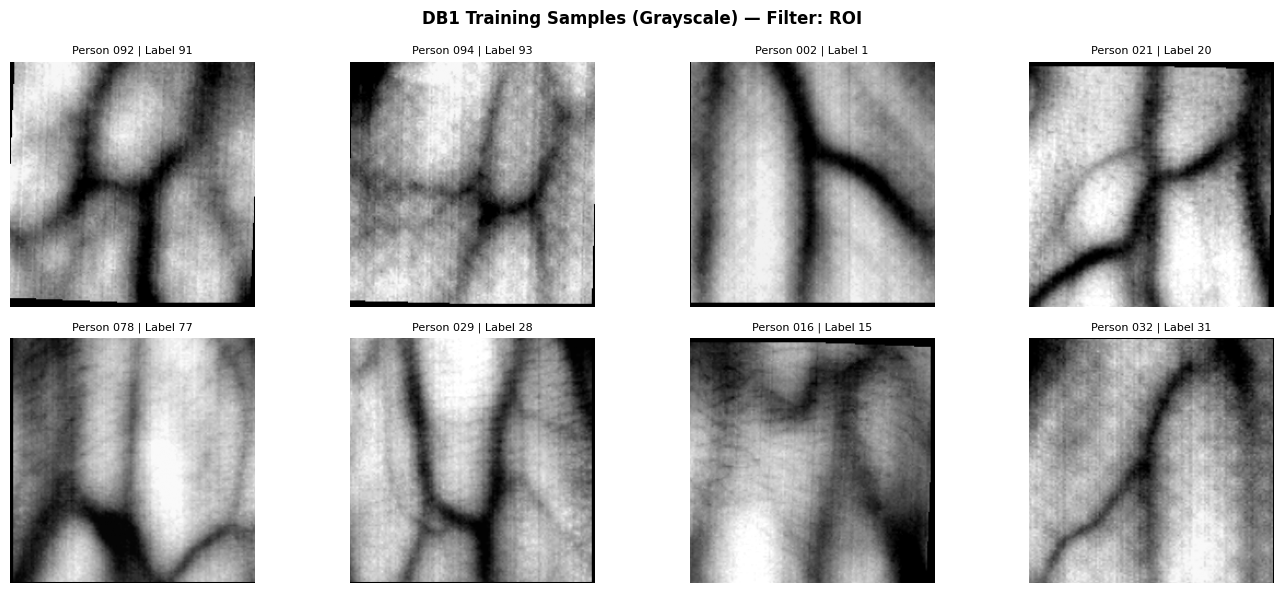

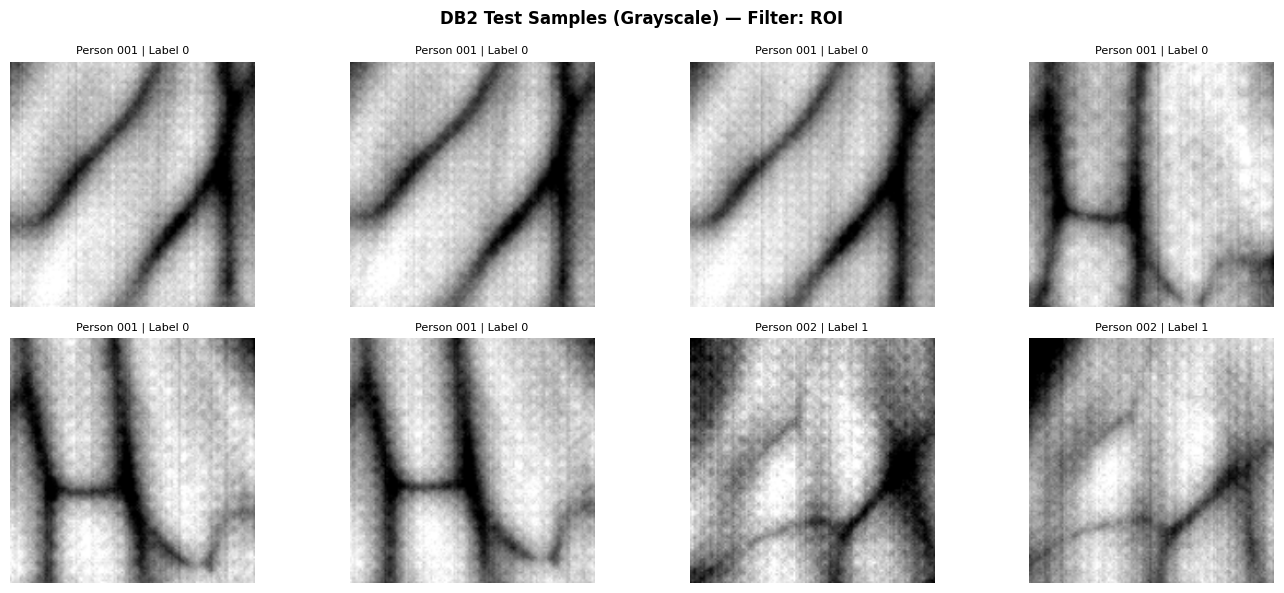

In [ ]:
# Cell 6 — Visualise Sample Images (FIXED FOR SINGLE-CHANNEL PARAMETERS)

def denormalize(tensor, mean=VEIN_MEAN, std=VEIN_STD):
    """Denormalizes a single-channel grayscale tensor back to a [0, 1] range."""
    t = tensor.clone()
    # Apply single-channel scalar denormalization directly
    t = t * std[0] + mean[0]
    return t.clamp(0, 1)

def visualise_batch(loader, dataset, n=8, title='Sample Batch'):
    imgs, labels = next(iter(loader))
    n = min(n, len(imgs))

    # Force n to be even to split across a 2-row layout cleanly
    if n % 2 != 0:
        n -= 1

    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    axes = axes.flatten()

    for i in range(n):
        # Squeeze out the channel dimension [1, H, W] -> [H, W] for grayscale rendering
        img_tensor = denormalize(imgs[i]).squeeze(0)
        img_np = img_tensor.numpy()

        pid = dataset.label_to_person[labels[i].item()]

        axes[i].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        axes[i].set_title(f'Person {pid:03d} | Label {labels[i].item()}', fontsize=8)
        axes[i].axis('off')

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run visualization to visually verify the CLAHE/Autocontrast and micro-augmentations
visualise_batch(train_loader, train_dataset, n=8,
                title=f'DB1 Training Samples (Grayscale) — Filter: {FILTER_TYPE.upper()}')
visualise_batch(test_loader,  test_dataset,  n=8,
                title=f'DB2 Test Samples (Grayscale) — Filter: {FILTER_TYPE.upper()}')

In [ ]:
# Cell 7 — Model 1: VeinCNN6 (Custom 6-Layer CNN) [ALIGNED FOR 1-CHANNEL GRAYSCALE]

class VeinCNN6(nn.Module):
    """
    Custom 6-layer CNN for dorsal hand vein identification.
    Input : (B, 1, 224, 224) -> Updated from 3 channels to 1 for grayscale vein parsing.
    Output: (B, 113) raw logits

    Architecture:
        Block 1: Conv(1->32)   BN ReLU MaxPool  -> 112x112
        Block 2: Conv(32->64)  BN ReLU MaxPool  ->  56x56
        Block 3: Conv(64->128) BN ReLU MaxPool  ->  28x28
        Block 4: Conv(128->256)BN ReLU MaxPool  ->  14x14
        Block 5: Conv(256->256)BN ReLU          ->  14x14
        Block 6: Conv(256->512)BN ReLU GAP      ->   1x1
        Head   : Dropout FC(512->256) ReLU FC(256->113)
    """
    def __init__(self, num_classes=113, dropout=0.5):
        super(VeinCNN6, self).__init__()

        def conv_block(in_ch, out_ch, pool=True):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            return nn.Sequential(*layers)

        # FIX: Changed input channel parameter from 3 to 1 to match the new dataset stream
        self.block1 = conv_block(1,   32,  pool=True)
        self.block2 = conv_block(32,  64,  pool=True)
        self.block3 = conv_block(64,  128, pool=True)
        self.block4 = conv_block(128, 256, pool=True)
        self.block5 = conv_block(256, 256, pool=False)
        self.block6 = conv_block(256, 512, pool=False)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


cnn_model = VeinCNN6(num_classes=NUM_CLASSES).to(DEVICE)
print('='*60)
print('  MODEL 1: VeinCNN6 — Custom 6-Layer CNN')
print('='*60)

# FIX: Modified the input channel size dimension from (1, 3, ...) to (1, 1, ...)
# to keep summary operations accurate with structural tensor updates.
summary(cnn_model, input_size=(1, 1, IMAGE_SIZE, IMAGE_SIZE),
        col_names=['input_size','output_size','num_params'], verbose=0)

  MODEL 1: VeinCNN6 — Custom 6-Layer CNN


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
VeinCNN6                                 [1, 1, 224, 224]          [1, 113]                  --
├─Sequential: 1-1                        [1, 1, 224, 224]          [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 1, 224, 224]          [1, 32, 224, 224]         288
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 32, 224, 224]         [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 32, 112, 112]         [1, 64, 56, 56]           --
│    └─Conv2d: 2-5                       [1, 32, 112, 112]         [1, 64, 112, 112]         18,432
│    └─BatchNorm2d: 2-6                  [1, 64, 112, 112]         [1, 64, 112, 112]         128
│    └─ReLU: 2-7             

In [ ]:
# Cell 9 — Training & Evaluation Utilities (OPTIMIZED FOR 113-CLASS GRAYSCALE)

import copy
import time
from torch.utils.data import Subset

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model, model_name, train_loader, test_loader,
                num_epochs, lr, weight_decay, device, save_dir):

    # FIX 1: Raised label smoothing to 0.10 to help absorb Left/Right geometric layout conflicts
    criterion = nn.CrossEntropyLoss(label_smoothing=0.10)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )

    # FIX 2: Create a deterministic, isolated internal validation subset from DB1 to track
    # checkpoint health fairly without peaking or leaking information from the DB2 Test Set.
    base_dataset = train_loader.dataset
    indices = list(range(len(base_dataset)))
    np.random.seed(42)
    np.random.shuffle(indices)
    val_split = max(1, int(len(base_dataset) * 0.15)) # 15% validation split

    val_indices, train_indices = indices[:val_split], indices[val_split:]

    internal_train_dataset = Subset(base_dataset, train_indices)
    internal_val_dataset   = Subset(base_dataset, val_indices)

    # Adjust dataloaders dynamically for split
    sub_train_loader = DataLoader(internal_train_dataset, batch_size=train_loader.batch_size,
                                  shuffle=True, num_workers=2, pin_memory=train_loader.pin_memory)
    sub_val_loader   = DataLoader(internal_val_dataset, batch_size=train_loader.batch_size,
                                  shuffle=False, num_workers=2, pin_memory=train_loader.pin_memory)

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'test_loss':[], 'test_acc':[]}
    best_val_loss, best_state = float('inf'), None
    best_preds, best_labels = None, None
    save_path = os.path.join(save_dir, f'{model_name}_best.pth')

    print(f'\n{"="*75}')
    print(f'  Training : {model_name}  |  Epochs: {num_epochs}')
    print(f'  Filter   : {FILTER_TYPE.upper()}  |  Train/Val->DB1 Split  Test->DB2')
    print(f'{"="*75}')
    print(f'{"Epoch":>5} | {"Tr Loss":>7} | {"Tr Acc":>6} | {"Val Loss":>8} | {"Val Acc":>7} | {"Te Acc":>6}')
    print('-'*75)

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        # Train on the subset of DB1
        tr_loss, tr_acc = train_one_epoch(model, sub_train_loader, criterion, optimizer, device)

        # Validate on the remaining subset of DB1
        val_loss, val_acc, _, _ = evaluate(model, sub_val_loader, criterion, device)

        # Fair benchmark testing on DB2
        te_loss, te_acc, preds, labels = evaluate(model, test_loader, criterion, device)

        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc' ].append(tr_acc)
        history['val_loss'  ].append(val_loss)
        history['val_acc'   ].append(val_acc)
        history['test_loss' ].append(te_loss)
        history['test_acc'  ].append(te_acc)

        # Save checkpoint strictly based on lowest internal validation loss to ensure generalization
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model.state_dict())
            best_preds    = preds
            best_labels   = labels
            torch.save({
                'epoch'      : epoch,
                'model_state': best_state,
                'optimizer'  : optimizer.state_dict(),
                'test_acc'   : te_acc,
                'filter_type': FILTER_TYPE,
            }, save_path)
            marker = ' [Saved Checkpoint]'
        else:
            marker = ''

        elapsed = time.time() - t0
        print(f'{epoch:>5} | {tr_loss:>7.4f} | {tr_acc*100:>5.1f}% | '
              f'{val_loss:>8.4f} | {val_acc*100:>6.1f}% | {te_acc*100:>5.1f}%{marker} [{elapsed:.1f}s]')

    print('-'*75)
    model.load_state_dict(best_state)
    # Print out evaluation summary using true saved generalized parameters
    _, final_test_acc, _, _ = evaluate(model, test_loader, criterion, device)
    print(f'Generalized Test Accuracy on Saved Weights: {final_test_acc*100:.2f}%')
    print(f'Saved checkpoint  : {save_path}')
    return history, best_preds, best_labels

print('Training utilities defined.')

Training utilities defined.


In [ ]:
# Cell 10 — Plot Utilities (EXPANDED FOR VALIDATION INTEGRATION)

def plot_history(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train Loss (DB1 Sub)')
    ax1.plot(epochs, history['val_loss'],   'g-o', markersize=3, label='Val Loss (DB1 Sub)')
    ax1.plot(epochs, history['test_loss'],  'r-o', markersize=3, label='Test Loss (DB2 Benchmark)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.set_title(f'{model_name} — Loss Curve')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(epochs, [a*100 for a in history['train_acc']],   'b-o', markersize=3, label='Train Acc (DB1 Sub)')
    ax2.plot(epochs, [a*100 for a in history['val_acc']],     'g-o', markersize=3, label='Val Acc (DB1 Sub)')
    ax2.plot(epochs, [a*100 for a in history['test_acc']],    'r-o', markersize=3, label='Test Acc (DB2 Benchmark)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{model_name} — Accuracy Curve')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle(
        f'{model_name}  |  Filter: {FILTER_TYPE.upper()}  |  Train/Val Split Setup',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{model_name}_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(labels, preds, model_name, max_classes=30):
    cm   = confusion_matrix(labels, preds)
    n    = cm.shape[0]
    size = max(10, n // 5)
    fig, ax = plt.subplots(figsize=(size, size))
    sns.heatmap(
        cm, ax=ax, cmap='Blues',
        fmt='d'   if n <= max_classes else '',
        annot     = n <= max_classes,
        xticklabels = range(n) if n <= max_classes else False,
        yticklabels = range(n) if n <= max_classes else False,
        linewidths  = 0.3 if n <= max_classes else 0,
    )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(
        f'{model_name} — Confusion Matrix\n'
        f'DB2 Test Set | {n} Classes | Filter: {FILTER_TYPE.upper()}'
    )
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{model_name}_confusion.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


def print_classification_report(labels, preds, model_name):
    acc = accuracy_score(labels, preds)
    print(f'\n{"="*65}')
    print(f'  {model_name} — Classification Report (DB2 Test Set)')
    print(f'  Filter: {FILTER_TYPE.upper()}  |  Overall Accuracy: {acc*100:.2f}%')
    print(f'{"="*65}')
    person_names = [f'P{i+1:03d}' for i in range(NUM_CLASSES)]
    print(classification_report(
        labels, preds,
        target_names=person_names,
        digits=4,
        zero_division=0,
    ))

print('Plot utilities defined.')

Plot utilities defined.


In [ ]:
# Cell 11 — Train VeinCNN6

cnn_history, cnn_preds, cnn_labels = train_model(
    model        = cnn_model,
    model_name   = 'VeinCNN6',
    train_loader = train_loader,
    test_loader  = test_loader,
    num_epochs   = NUM_EPOCHS,
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY,
    device       = DEVICE,
    save_dir     = SAVE_DIR,
)


  Training : VeinCNN6  |  Epochs: 30
  Filter   : ROI  |  Train/Val->DB1 Split  Test->DB2
Epoch | Tr Loss | Tr Acc | Val Loss | Val Acc | Te Acc
---------------------------------------------------------------------------
    1 |  4.7820 |   1.6% |   5.4636 |    0.0% |   0.9% [Saved Checkpoint] [7.2s]
    2 |  4.5215 |   2.9% |   7.5945 |    0.0% |   0.9% [7.7s]
    3 |  4.2751 |   6.5% |   4.6363 |    2.2% |   1.9% [Saved Checkpoint] [8.6s]
    4 |  4.0559 |   7.4% |   4.8388 |    3.0% |   1.8% [6.9s]
    5 |  3.8245 |  12.7% |   3.9713 |    8.1% |   5.3% [Saved Checkpoint] [8.9s]
    6 |  3.6293 |  14.2% |   3.9952 |    9.6% |  11.4% [6.9s]
    7 |  3.4198 |  22.0% |   4.4745 |    5.2% |   4.3% [8.8s]
    8 |  3.2450 |  27.3% |   3.7611 |   15.6% |  11.1% [Saved Checkpoint] [6.8s]
    9 |  3.0453 |  33.7% |   4.6043 |    7.4% |   5.8% [8.2s]
   10 |  2.8603 |  40.8% |   3.3612 |   20.7% |  12.4% [Saved Checkpoint] [7.7s]
   11 |  2.6887 |  45.8% |   3.2892 |   20.7% |  11.2% [Saved C

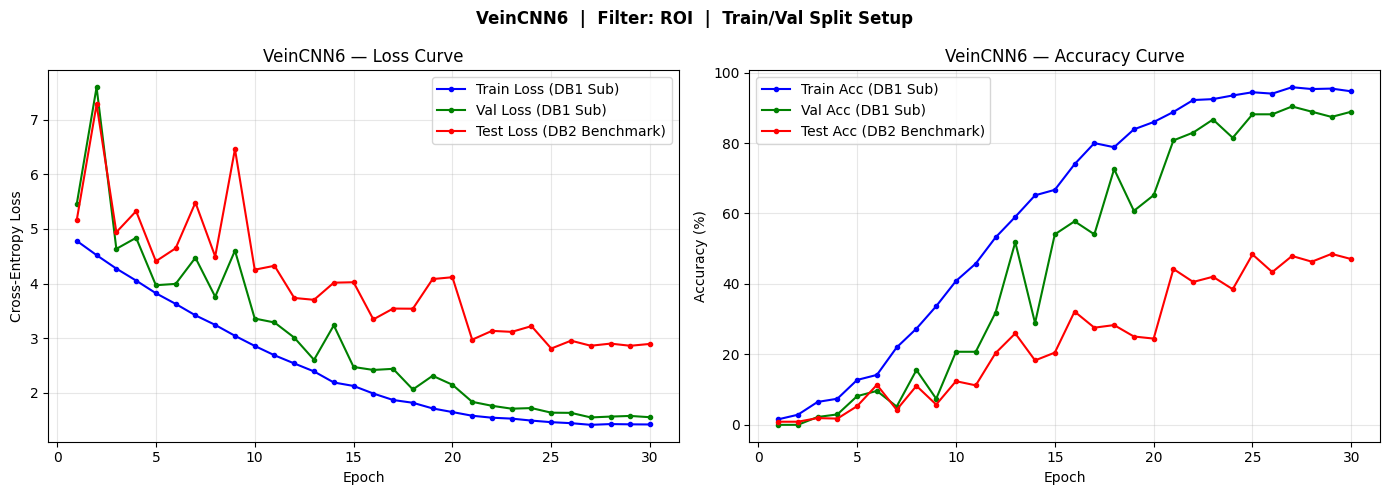

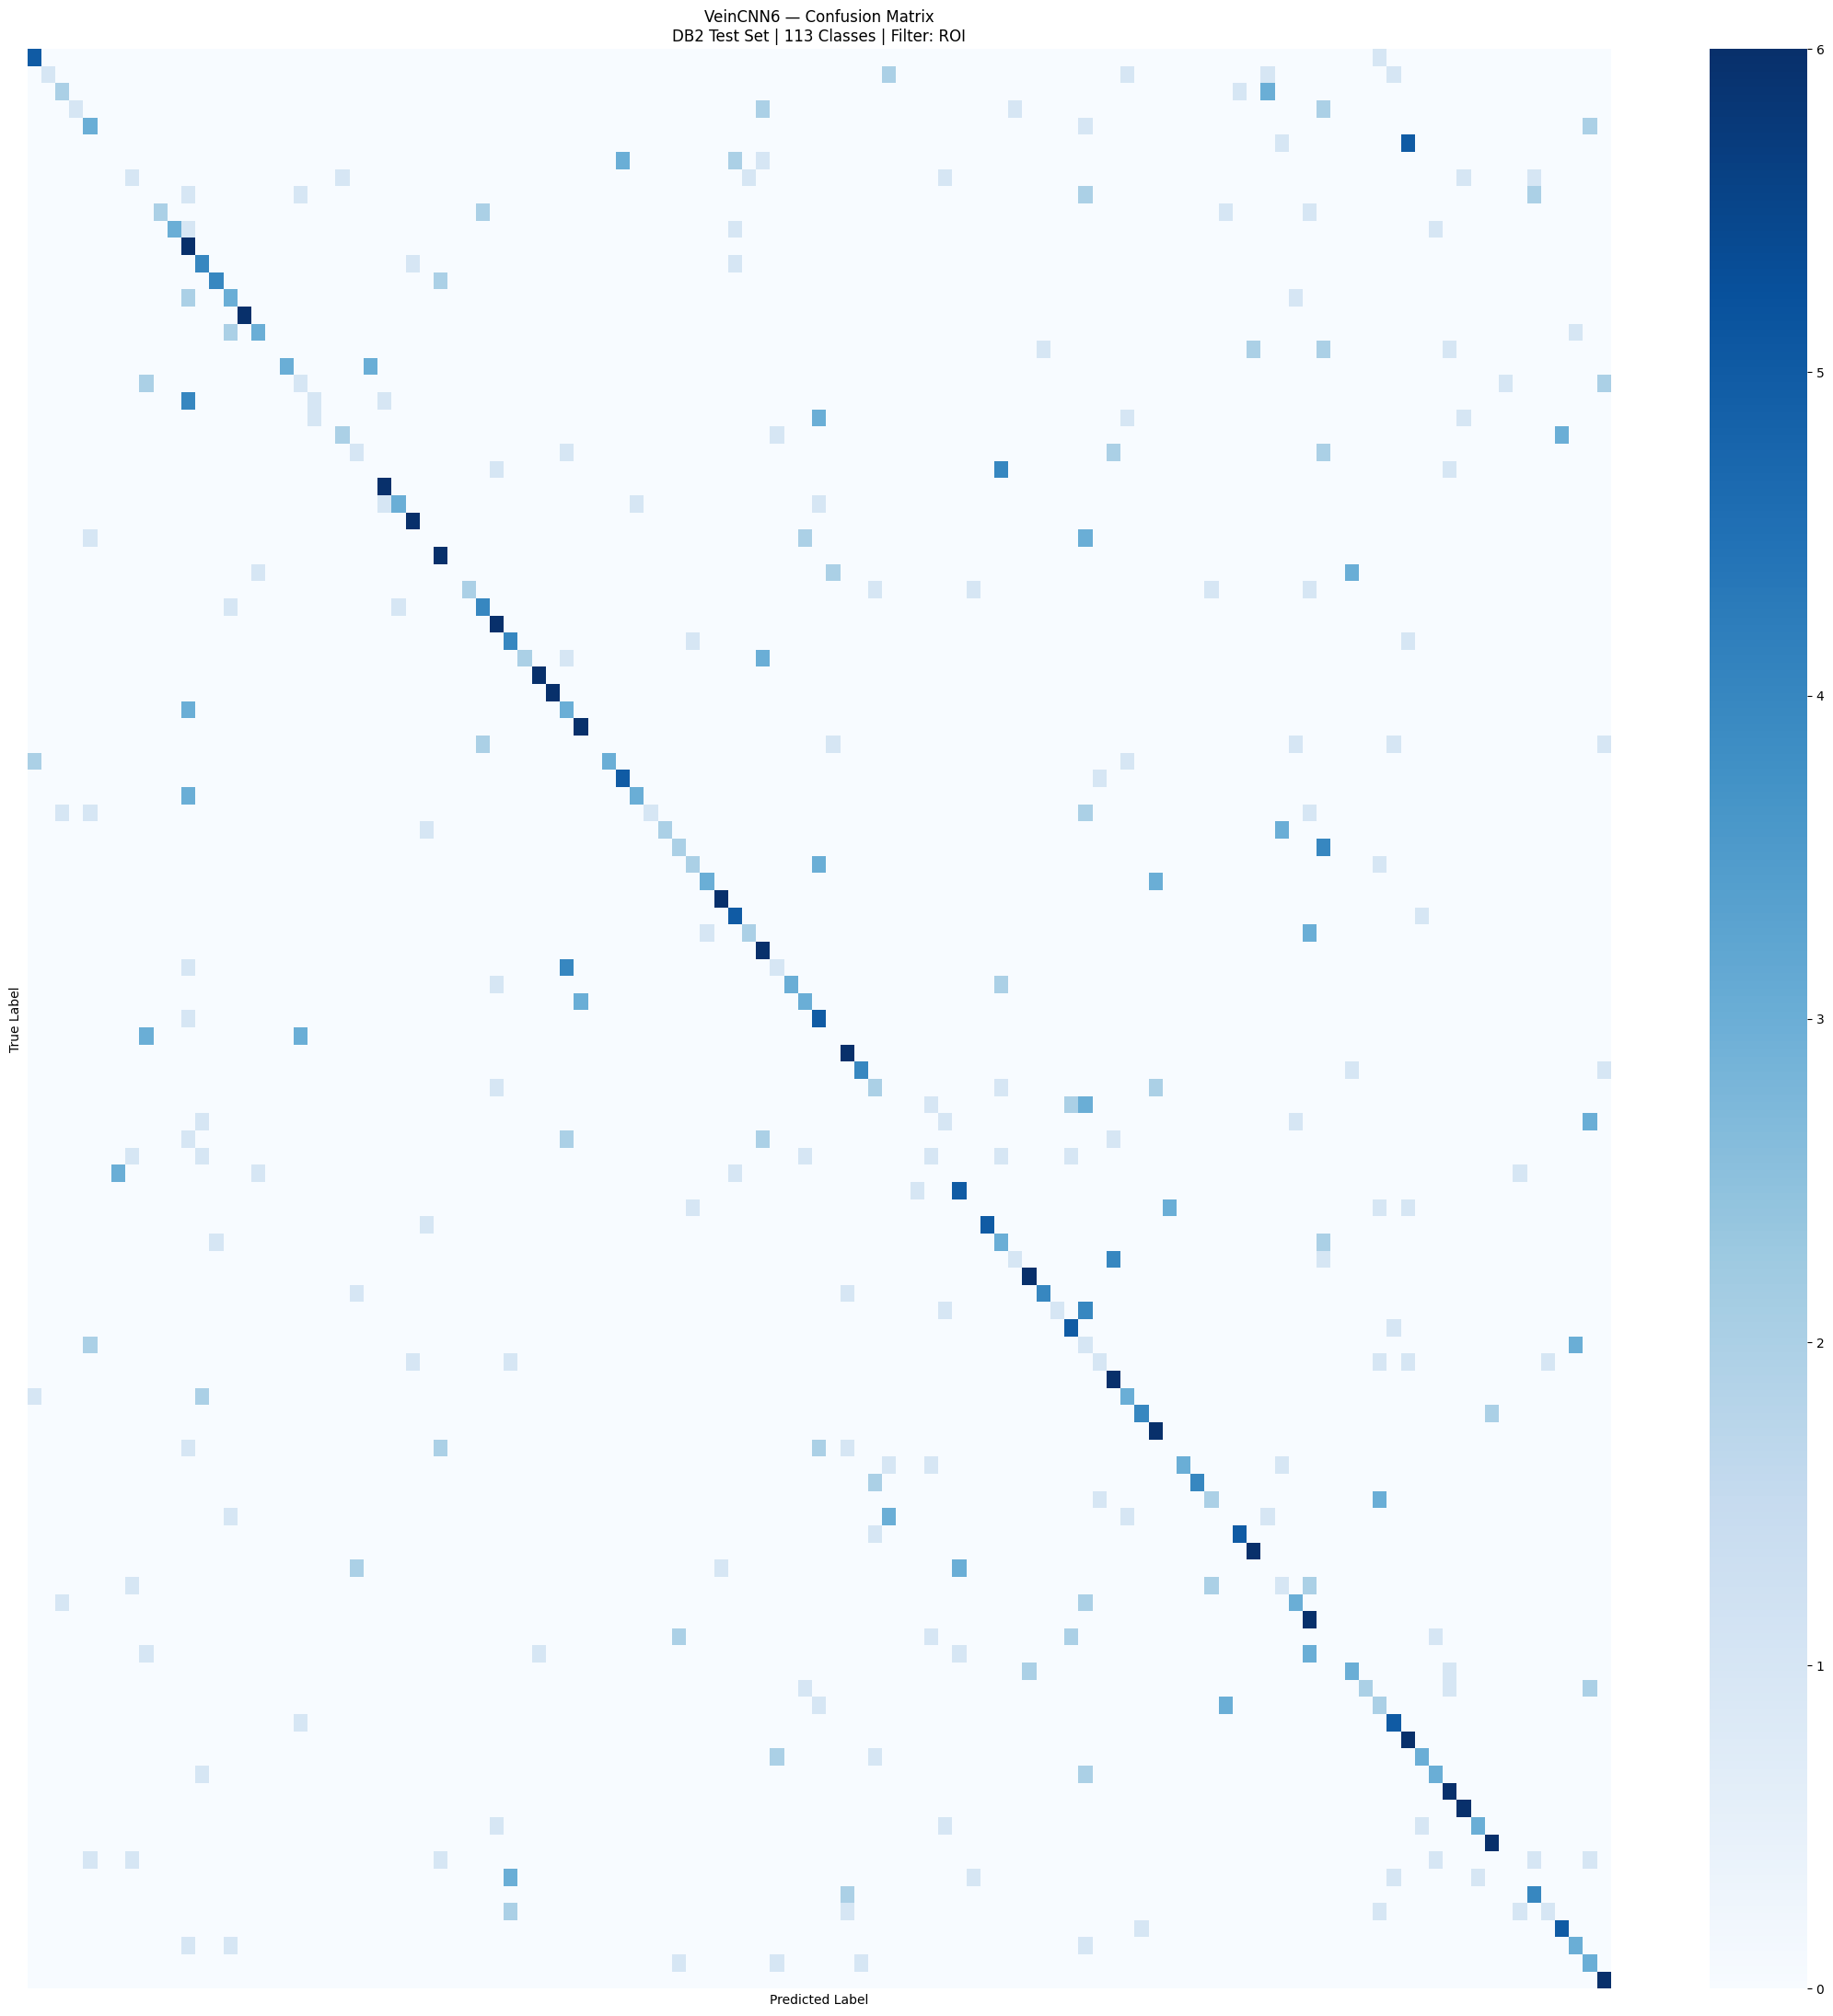


  VeinCNN6 — Classification Report (DB2 Test Set)
  Filter: ROI  |  Overall Accuracy: 47.94%
              precision    recall  f1-score   support

        P001     0.6250    0.8333    0.7143         6
        P002     1.0000    0.1667    0.2857         6
        P003     0.5000    0.3333    0.4000         6
        P004     1.0000    0.1667    0.2857         6
        P005     0.3750    0.5000    0.4286         6
        P006     0.0000    0.0000    0.0000         6
        P007     0.0000    0.0000    0.0000         6
        P008     0.2500    0.1667    0.2000         6
        P009     0.0000    0.0000    0.0000         6
        P010     1.0000    0.3333    0.5000         6
        P011     1.0000    0.5000    0.6667         6
        P012     0.2400    1.0000    0.3871         6
        P013     0.4444    0.6667    0.5333         6
        P014     0.8000    0.6667    0.7273         6
        P015     0.3750    0.5000    0.4286         6
        P016     1.0000    1.0000    1.00

In [ ]:
# Cell 12 — Evaluate VeinCNN6
plot_history(cnn_history, model_name='VeinCNN6')
plot_confusion_matrix(cnn_labels, cnn_preds, model_name='VeinCNN6')
print_classification_report(cnn_labels, cnn_preds, model_name='VeinCNN6')